# Notebook 06: SHAP Analysis
Opx ML Thermobarometer
Author: [Your name]
Date: 2026-04-04

This notebook uses SHAP to explain model predictions and identify feature importance.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from config import (ROOT, DATA_RAW, DATA_PROC, DATA_SPLITS, DATA_NATURAL,
                    MODELS, FIGURES, RESULTS, LOGS, EXPETDB)

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

c:\Users\NQTa\Documents\MLCourse\Final Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 6.1 Load best models and test data

In [2]:
model_P = joblib.load(MODELS / 'model_RF_P_kbar_opx_liq.joblib')
model_T = joblib.load(MODELS / 'model_RF_T_C_opx_liq.joblib')

df_liq_full = pd.read_parquet(DATA_PROC / 'opx_clean_opx_liq.parquet')
test_idx = np.load(DATA_SPLITS / 'test_indices_opx_liq.npy')
df_test_liq = df_liq_full.loc[test_idx].copy()

OPX_FEAT = ['SiO2','Al2O3','FeO_total','MgO','CaO','Mg_num','Al_IV','Al_VI','En_frac','Fs_frac','Wo_frac','MgTs']
LIQ_OXIDES = ['SiO2','TiO2','Al2O3','FeO','MgO','CaO','Na2O','K2O']
liq_feat = [f'liq_{o}' for o in LIQ_OXIDES] + ['liq_Mg_num']
ALL_FEAT = OPX_FEAT + liq_feat

X_test = df_test_liq[ALL_FEAT].fillna(0).values
print(f'SHAP test set: {len(X_test)} samples')

SHAP test set: 170 samples


## 6.2 SHAP analysis for pressure model

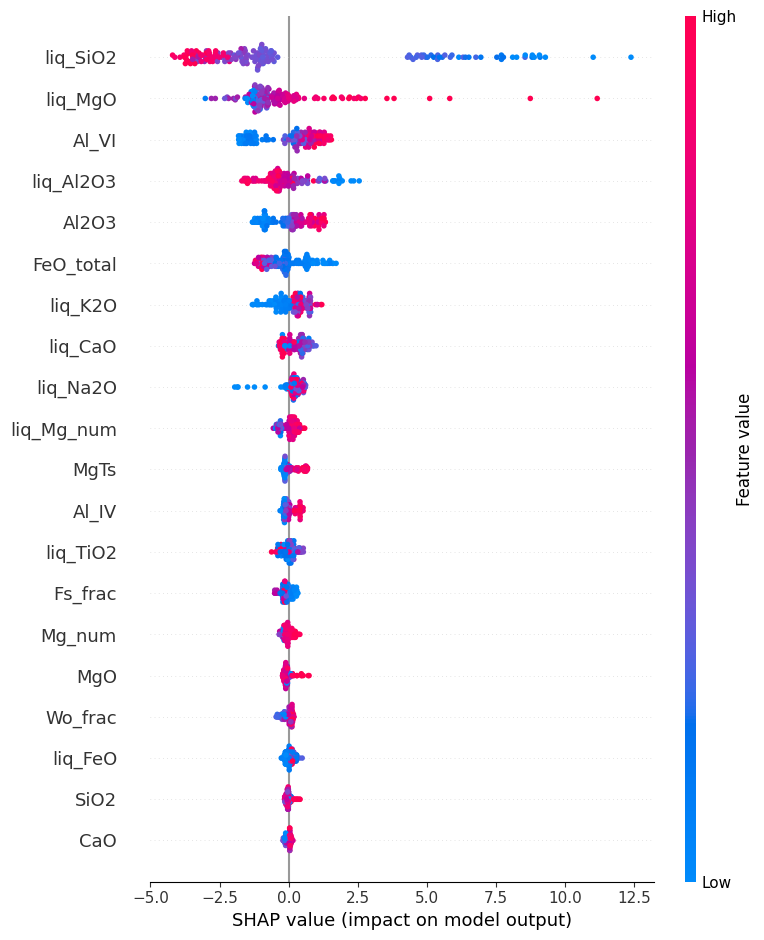

Saved fig07_shap_P_beeswarm.png


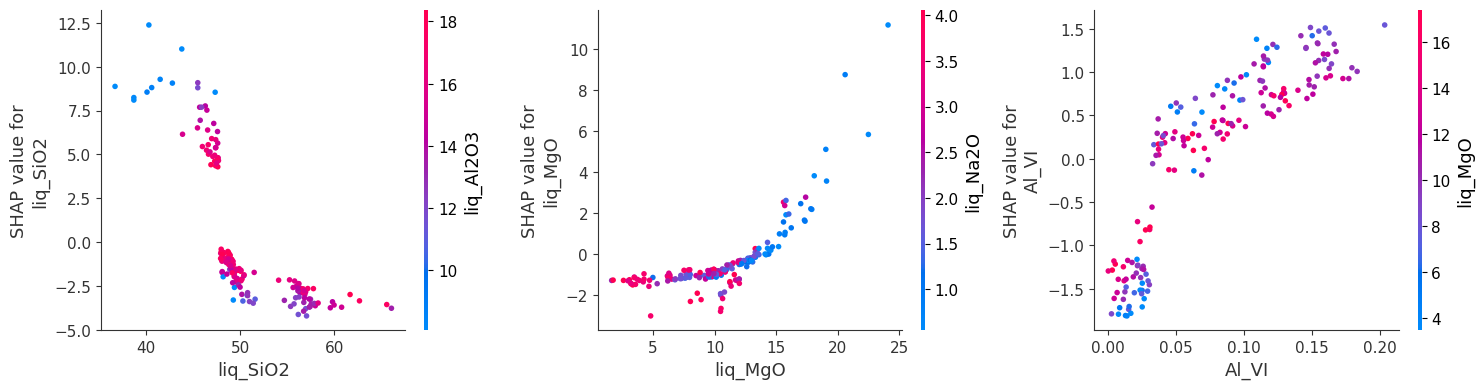

Saved fig09_shap_P_dependence.png


In [3]:
explainer_P = shap.TreeExplainer(model_P)
shap_values_P = explainer_P.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_P, X_test, feature_names=ALL_FEAT, show=False)
plt.savefig(FIGURES / 'fig07_shap_P_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig07_shap_P_beeswarm.png')

feature_importance_P = np.abs(shap_values_P).mean(0)
top3_P = np.argsort(feature_importance_P)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat_idx in enumerate(top3_P):
    shap.dependence_plot(feat_idx, shap_values_P, X_test, feature_names=ALL_FEAT, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURES / 'fig09_shap_P_dependence.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig09_shap_P_dependence.png')

## 6.3 SHAP analysis for temperature model

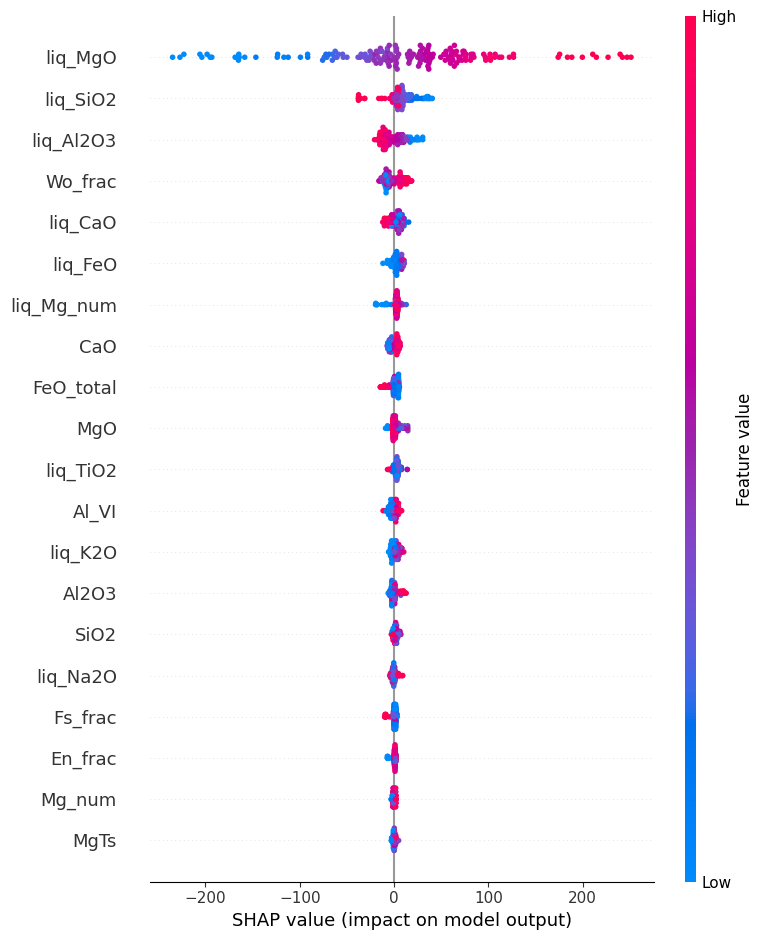

Saved fig08_shap_T_beeswarm.png


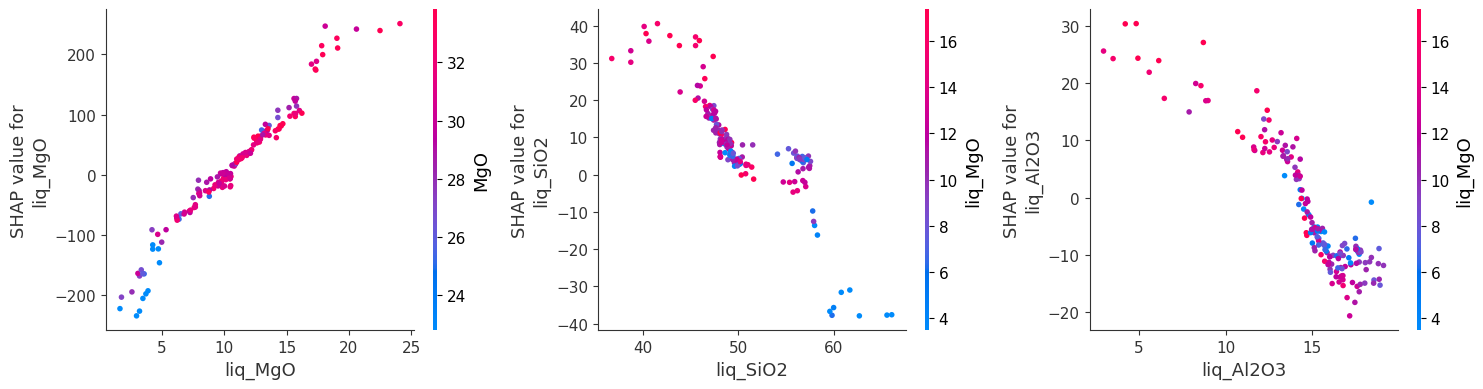

Saved fig09_shap_T_dependence.png

Notebook 06 complete.


In [4]:
explainer_T = shap.TreeExplainer(model_T)
shap_values_T = explainer_T.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_T, X_test, feature_names=ALL_FEAT, show=False)
plt.savefig(FIGURES / 'fig08_shap_T_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig08_shap_T_beeswarm.png')

feature_importance_T = np.abs(shap_values_T).mean(0)
top3_T = np.argsort(feature_importance_T)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat_idx in enumerate(top3_T):
    shap.dependence_plot(feat_idx, shap_values_T, X_test, feature_names=ALL_FEAT, ax=axes[i], show=False)
plt.tight_layout()
plt.savefig(FIGURES / 'fig09_shap_T_dependence.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close()
print('Saved fig09_shap_T_dependence.png')

feat_imp_P = pd.DataFrame({'feature': ALL_FEAT, 'importance_P': feature_importance_P})
feat_imp_T = pd.DataFrame({'feature': ALL_FEAT, 'importance_T': feature_importance_T})
feat_imp = feat_imp_P.merge(feat_imp_T, on='feature')
feat_imp.to_csv(RESULTS / 'nb06_shap_feature_importance.csv', index=False)

print('\nNotebook 06 complete.')